# 61 — Regression Models: AUB + Peers Merged Data

Predict raw citation counts (via log1p transform) using the full merged dataset  
(AUB + peer universities, 2015–2020).  

**Two evaluation scenarios**
- **Scenario A** — all-unis test set (2018–2020, all institutions)
- **Scenario B** — AUB-only test set (2018–2020, AUB papers only)

**Metrics**: RMSE, MAE, R², Spearman ρ (on log scale)  
**Bonus**: rank-based classification via regression threshold

In [29]:
import sys
sys.path.append('../../')

import re
import pickle
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import spearmanr

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    f1_score, roc_auc_score, make_scorer
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
%matplotlib inline

# ── AUB-only classification baseline (from nb30/31) ───────────────────────────
BASELINE_F1  = 0.6255   # AUB-only LogReg classification baseline
BASELINE_AUC = 0.8104
print('Imports OK')

Imports OK


## 1. Load Merged Data

In [30]:
data_path = Path('../../data/processed/all_unis_cleaned.pkl')

if not data_path.exists():
    raise FileNotFoundError(
        f"Merged data not found: {data_path}\n"
        "Run notebooks 04 → 05 → 06 first to generate the merged dataset."
    )

df = pd.read_pickle(data_path)
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"\nRows per institution:")
print(df['institution'].value_counts().to_string())
print(f"\nYear range: {df['Year'].min()} – {df['Year'].max()}")
print(f"\nCitation stats:")
print(df['Citations'].describe().to_string())

Loaded: 39,391 rows x 69 cols

Rows per institution:
institution
AUB          14832
Lehigh        9848
Marquette     8403
Villanova     6308

Year range: 2010 – 2025

Citation stats:
count    39391.000000
mean        30.323043
std        373.796244
min          0.000000
25%          3.000000
50%         11.000000
75%         27.000000
max      66291.000000


## 2. Temporal Train/Test Split

In [31]:
TRAIN_YEARS = [2015, 2016, 2017]
TEST_YEARS  = [2018, 2019, 2020]

df_train     = df[df['Year'].isin(TRAIN_YEARS)].copy()
df_test      = df[df['Year'].isin(TEST_YEARS)].copy()
df_test_aub  = df_test[df_test['institution'] == 'AUB'].copy()

print("SPLIT SUMMARY")
print("=" * 50)
print(f"Train (2015-2017): {len(df_train):,} papers")
print(df_train['institution'].value_counts().to_string())
print(f"\nTest – all unis (2018-2020): {len(df_test):,} papers")
print(df_test['institution'].value_counts().to_string())
print(f"\nTest – AUB-only (2018-2020): {len(df_test_aub):,} papers")

SPLIT SUMMARY
Train (2015-2017): 6,255 papers
institution
AUB          2545
Marquette    1410
Lehigh       1249
Villanova    1051

Test – all unis (2018-2020): 8,871 papers
institution
AUB          3573
Lehigh       2107
Marquette    1870
Villanova    1321

Test – AUB-only (2018-2020): 3,573 papers


## 3. Regression Targets — log1p(Citations)

In [32]:
y_train_reg    = np.log1p(df_train['Citations'].clip(lower=0))
y_test_all_reg = np.log1p(df_test['Citations'].clip(lower=0))
y_test_aub_reg = np.log1p(df_test_aub['Citations'].clip(lower=0))

print(f"Train  log1p(cit): mean={y_train_reg.mean():.3f}  std={y_train_reg.std():.3f}  "
      f"range=[{y_train_reg.min():.2f}, {y_train_reg.max():.2f}]")
print(f"Test   log1p(cit): mean={y_test_all_reg.mean():.3f}  std={y_test_all_reg.std():.3f}  "
      f"range=[{y_test_all_reg.min():.2f}, {y_test_all_reg.max():.2f}]")
print(f"Test-AUB log1p(cit): mean={y_test_aub_reg.mean():.3f}  std={y_test_aub_reg.std():.3f}")

# Classification targets (for regression-as-classifier bonus)
merged_threshold = df_train['Citations'].quantile(0.75)
aub_threshold    = df_train.loc[df_train['institution'] == 'AUB', 'Citations'].quantile(0.75)

y_train_cls    = (df_train['Citations']    >= merged_threshold).astype(int)
y_test_all_cls = (df_test['Citations']     >= merged_threshold).astype(int)
y_test_aub_cls = (df_test_aub['Citations'] >= aub_threshold).astype(int)

print(f"\nMerged threshold (75th pct): {merged_threshold:.0f} cit  "
      f"→ {y_train_cls.mean()*100:.1f}% high-impact in train")
print(f"AUB threshold    (75th pct): {aub_threshold:.0f} cit  "
      f"→ {y_test_aub_cls.mean()*100:.1f}% high-impact in AUB test")

Train  log1p(cit): mean=2.873  std=1.241  range=[0.00, 8.73]
Test   log1p(cit): mean=2.689  std=1.207  range=[0.00, 10.17]
Test-AUB log1p(cit): mean=2.661  std=1.227

Merged threshold (75th pct): 39 cit  → 25.5% high-impact in train
AUB threshold    (75th pct): 38 cit  → 19.3% high-impact in AUB test


## 4. Feature Engineering

In [33]:
# ── TF-IDF ────────────────────────────────────────────────────────────────────
def preprocess_text(text):
    if pd.isna(text):
        return ""
    return str(text).lower()

tfidf = TfidfVectorizer(
    max_features=5000, ngram_range=(1, 2),
    min_df=5, max_df=0.8, stop_words='english'
)

abs_train   = df_train['Abstract'].apply(preprocess_text)
abs_test_all = df_test['Abstract'].apply(preprocess_text)
abs_test_aub = df_test_aub['Abstract'].apply(preprocess_text)

tfidf_train     = tfidf.fit_transform(abs_train)
tfidf_test_all  = tfidf.transform(abs_test_all)
tfidf_test_aub  = tfidf.transform(abs_test_aub)

feat_names = [f'tfidf_{f}' for f in tfidf.get_feature_names_out()]
text_train    = pd.DataFrame(tfidf_train.toarray(),    columns=feat_names, index=df_train.index)
text_test_all = pd.DataFrame(tfidf_test_all.toarray(), columns=feat_names, index=df_test.index)
text_test_aub = pd.DataFrame(tfidf_test_aub.toarray(), columns=feat_names, index=df_test_aub.index)

print(f"TF-IDF: {text_train.shape[1]} features")

TF-IDF: 5000 features


In [34]:
# ── Venue features ────────────────────────────────────────────────────────────
def build_venue_features(subset_df):
    vf = pd.DataFrame(index=subset_df.index)
    col_map = {
        'snip':                 'SNIP (publication year)',
        'snip_percentile':      'SNIP percentile (publication year) *',
        'citescore':            'CiteScore (publication year)',
        'citescore_percentile': 'CiteScore percentile (publication year) *',
        'sjr':                  'SJR (publication year)',
        'sjr_percentile':       'SJR percentile (publication year) *',
    }
    for feat, col in col_map.items():
        vf[feat] = pd.to_numeric(subset_df.get(col, pd.Series(np.nan, index=subset_df.index)),
                                 errors='coerce')
    vf['avg_venue_percentile'] = vf[['snip_percentile', 'citescore_percentile', 'sjr_percentile']].mean(axis=1)
    vf['venue_score_composite'] = (vf['snip'].fillna(0) + vf['sjr'].fillna(0) + vf['citescore'].fillna(0)) / 3
    vf['is_top_journal'] = (vf['avg_venue_percentile'] >= 75).astype(int)
    vf = vf.fillna(0)
    return vf

venue_train    = build_venue_features(df_train)
venue_test_all = build_venue_features(df_test)
venue_test_aub = build_venue_features(df_test_aub)
print(f"Venue features: {venue_train.shape[1]}")

Venue features: 9


In [35]:
# ── Author / collaboration features ──────────────────────────────────────────
def build_author_features(subset_df):
    af = pd.DataFrame(index=subset_df.index)
    for feat, col in [
        ('num_authors',      'Number of Authors'),
        ('num_institutions', 'Number of Institutions'),
        ('num_countries',    'Number of Countries/Regions'),
    ]:
        af[feat] = pd.to_numeric(
            subset_df.get(col, pd.Series(np.nan, index=subset_df.index)), errors='coerce'
        )
    af['is_single_author']        = (af['num_authors'] == 1).astype(int)
    af['is_international_collab'] = (af['num_countries'] > 1).astype(int)
    af['is_multi_institution']    = (af['num_institutions'] > 1).astype(int)
    af['authors_per_institution'] = af['num_authors'] / af['num_institutions'].replace(0, 1)
    af['team_size_small']  = (af['num_authors'] <= 3).astype(int)
    af['team_size_medium'] = ((af['num_authors'] > 3) & (af['num_authors'] <= 10)).astype(int)
    af['team_size_large']  = (af['num_authors'] > 10).astype(int)
    af = af.fillna(0)
    return af

author_train    = build_author_features(df_train)
author_test_all = build_author_features(df_test)
author_test_aub = build_author_features(df_test_aub)
print(f"Author features: {author_train.shape[1]}")

Author features: 10


In [36]:
# ── Metadata features ────────────────────────────────────────────────────────
def build_metadata_features(subset_df, pub_type_cols=None, source_type_cols=None):
    mf = pd.DataFrame(index=subset_df.index)
    mf['is_open_access'] = subset_df.get(
        'Open Access', pd.Series(np.nan, index=subset_df.index)
    ).notna().astype(int)
    mf['topic_prominence'] = pd.to_numeric(
        subset_df.get('Topic Prominence Percentile', pd.Series(np.nan, index=subset_df.index)),
        errors='coerce'
    )
    mf['topic_prominence'] = mf['topic_prominence'].fillna(mf['topic_prominence'].median())
    pub_dummies = pd.get_dummies(
        subset_df.get('Publication Type', pd.Series('Unknown', index=subset_df.index)),
        prefix='pubtype'
    )
    if pub_type_cols is not None:
        pub_dummies = pub_dummies.reindex(columns=pub_type_cols, fill_value=0)
    src_dummies = pd.get_dummies(
        subset_df.get('Source Type', pd.Series('Unknown', index=subset_df.index)),
        prefix='srctype'
    )
    if source_type_cols is not None:
        src_dummies = src_dummies.reindex(columns=source_type_cols, fill_value=0)
    mf = pd.concat([mf, pub_dummies, src_dummies], axis=1).fillna(0)
    return mf

meta_train = build_metadata_features(df_train)
pub_type_cols   = [c for c in meta_train.columns if c.startswith('pubtype')]
source_type_cols = [c for c in meta_train.columns if c.startswith('srctype')]
meta_test_all = build_metadata_features(df_test,     pub_type_cols, source_type_cols)
meta_test_aub = build_metadata_features(df_test_aub, pub_type_cols, source_type_cols)
print(f"Metadata features: {meta_train.shape[1]}")

Metadata features: 4


In [37]:
# ── Interaction + temporal features ──────────────────────────────────────────
def build_interaction_features(venue_df, author_df):
    ix = pd.DataFrame(index=venue_df.index)
    ix['top_journal_x_intl_collab']    = venue_df['is_top_journal']       * author_df['is_international_collab']
    ix['venue_pct_x_num_authors']      = venue_df['avg_venue_percentile'] * author_df['num_authors']
    ix['venue_pct_x_num_institutions'] = venue_df['avg_venue_percentile'] * author_df['num_institutions']
    return ix

REFERENCE_YEAR = 2024

def build_temporal_features(subset_df):
    tf = pd.DataFrame(index=subset_df.index)
    pub_year = pd.to_numeric(
        subset_df.get('Year', pd.Series(REFERENCE_YEAR, index=subset_df.index)), errors='coerce'
    ).fillna(REFERENCE_YEAR)
    tf['pub_year']               = pub_year
    tf['years_since_publication'] = REFERENCE_YEAR - pub_year
    return tf

interaction_train    = build_interaction_features(venue_train,    author_train)
interaction_test_all = build_interaction_features(venue_test_all, author_test_all)
interaction_test_aub = build_interaction_features(venue_test_aub, author_test_aub)

temporal_train    = build_temporal_features(df_train)
temporal_test_all = build_temporal_features(df_test)
temporal_test_aub = build_temporal_features(df_test_aub)

print(f"Interaction features: {interaction_train.shape[1]}")
print(f"Temporal features:    {temporal_train.shape[1]}")

Interaction features: 3
Temporal features:    2


In [38]:
# ── Assemble feature matrices ─────────────────────────────────────────────────
def assemble(text, venue, author, meta, interaction, temporal):
    X = pd.concat([text, venue, author, meta, interaction, temporal], axis=1)
    # Drop year-token TF-IDF columns to prevent leakage
    year_cols = [c for c in X.columns if re.match(r'tfidf_\d{4}$', c)]
    return X.drop(columns=year_cols, errors='ignore')

X_train    = assemble(text_train,    venue_train,    author_train,    meta_train,    interaction_train,    temporal_train)
X_test_all = assemble(text_test_all, venue_test_all, author_test_all, meta_test_all, interaction_test_all, temporal_test_all)
X_test_aub = assemble(text_test_aub, venue_test_aub, author_test_aub, meta_test_aub, interaction_test_aub, temporal_test_aub)

print(f"X_train:    {X_train.shape}")
print(f"X_test_all: {X_test_all.shape}")
print(f"X_test_aub: {X_test_aub.shape}")

X_train:    (6255, 5009)
X_test_all: (8871, 5009)
X_test_aub: (3573, 5009)


## 5. Define Models & Helpers

In [39]:
MODELS = {
    'Linear Regression': LinearRegression(n_jobs=-1),
    'Ridge':             Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(
                             n_estimators=200, max_depth=20,
                             random_state=42, n_jobs=-1),
    'XGBoost':           XGBRegressor(
                             n_estimators=300, max_depth=5, learning_rate=0.05,
                             random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM':          LGBMRegressor(
                             n_estimators=300, max_depth=5, learning_rate=0.05,
                             random_state=42, n_jobs=-1, verbose=-1),
}

def spearman_scorer(y_true, y_pred):
    return spearmanr(y_true, y_pred)[0]

spearman_score = make_scorer(spearman_scorer)

def reg_metrics(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    spr  = spearmanr(y_true, y_pred)[0]
    if label:
        print(f"  {label}: RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  Spearman={spr:.4f}")
    return dict(rmse=rmse, mae=mae, r2=r2, spearman=spr)

print(f"Models: {list(MODELS.keys())}")

Models: ['Linear Regression', 'Ridge', 'Random Forest', 'XGBoost', 'LightGBM']


## 6. Cross-Validation on Train Set

In [40]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'mse':      'neg_mean_squared_error',
    'mae':      'neg_mean_absolute_error',
    'r2':       'r2',
    'spearman': spearman_score,
}

cv_results = {}
for name, model in MODELS.items():
    print(f"CV: {name}...")
    scores = cross_validate(model, X_train, y_train_reg, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'rmse':     np.sqrt(-scores['test_mse'].mean()),
        'mae':      -scores['test_mae'].mean(),
        'r2':       scores['test_r2'].mean(),
        'spearman': scores['test_spearman'].mean(),
    }
    r = cv_results[name]
    print(f"  RMSE={r['rmse']:.4f}  MAE={r['mae']:.4f}  R²={r['r2']:.4f}  Spearman={r['spearman']:.4f}")

cv_df = pd.DataFrame(cv_results).T
print("\nCV Summary:")
print(cv_df.to_string())

CV: Linear Regression...
  RMSE=11.9822  MAE=9.2537  R²=-90.8736  Spearman=0.0405
CV: Ridge...
  RMSE=0.9752  MAE=0.7654  R²=0.3805  Spearman=0.6031
CV: Random Forest...
  RMSE=0.9480  MAE=0.7419  R²=0.4157  Spearman=0.6198
CV: XGBoost...
  RMSE=0.9407  MAE=0.7380  R²=0.4245  Spearman=0.6238
CV: LightGBM...
  RMSE=0.9386  MAE=0.7364  R²=0.4269  Spearman=0.6261

CV Summary:
                        rmse       mae         r2  spearman
Linear Regression  11.982169  9.253729 -90.873627  0.040479
Ridge               0.975195  0.765398   0.380523  0.603069
Random Forest       0.947969  0.741887   0.415706  0.619769
XGBoost             0.940654  0.738030   0.424471  0.623839
LightGBM            0.938575  0.736401   0.426911  0.626145


## 7. Train on Full Training Set & Evaluate on Test Sets

In [41]:
trained_models  = {}
preds_all       = {}
preds_aub       = {}
test_results_all = {}
test_results_aub = {}

for name, model in MODELS.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train_reg)
    trained_models[name] = model

    preds_all[name] = model.predict(X_test_all)
    preds_aub[name] = model.predict(X_test_aub)

    test_results_all[name] = reg_metrics(y_test_all_reg, preds_all[name], label='All-unis')
    test_results_aub[name] = reg_metrics(y_test_aub_reg, preds_aub[name], label='AUB-only')

test_df_all = pd.DataFrame(test_results_all).T
test_df_aub = pd.DataFrame(test_results_aub).T

print("\n── All-unis test ──")
print(test_df_all.to_string())
print("\n── AUB-only test ──")
print(test_df_aub.to_string())


Training Linear Regression...
  All-unis: RMSE=2.2210  MAE=1.7402  R²=-2.3868  Spearman=0.2429
  AUB-only: RMSE=2.1987  MAE=1.7213  R²=-2.2144  Spearman=0.2397

Training Ridge...
  All-unis: RMSE=0.9879  MAE=0.7566  R²=0.3300  Spearman=0.5975
  AUB-only: RMSE=1.0412  MAE=0.7752  R²=0.2792  Spearman=0.5988

Training Random Forest...
  All-unis: RMSE=0.9544  MAE=0.7437  R²=0.3746  Spearman=0.6265
  AUB-only: RMSE=0.9804  MAE=0.7626  R²=0.3609  Spearman=0.6188

Training XGBoost...
  All-unis: RMSE=0.9495  MAE=0.7404  R²=0.3811  Spearman=0.6305
  AUB-only: RMSE=0.9812  MAE=0.7620  R²=0.3598  Spearman=0.6271

Training LightGBM...
  All-unis: RMSE=0.9496  MAE=0.7415  R²=0.3809  Spearman=0.6299
  AUB-only: RMSE=0.9782  MAE=0.7623  R²=0.3637  Spearman=0.6286

── All-unis test ──
                       rmse       mae        r2  spearman
Linear Regression  2.221033  1.740205 -2.386785  0.242925
Ridge              0.987860  0.756574  0.330009  0.597539
Random Forest      0.954396  0.743732  0.37

## 8. Visualise Results

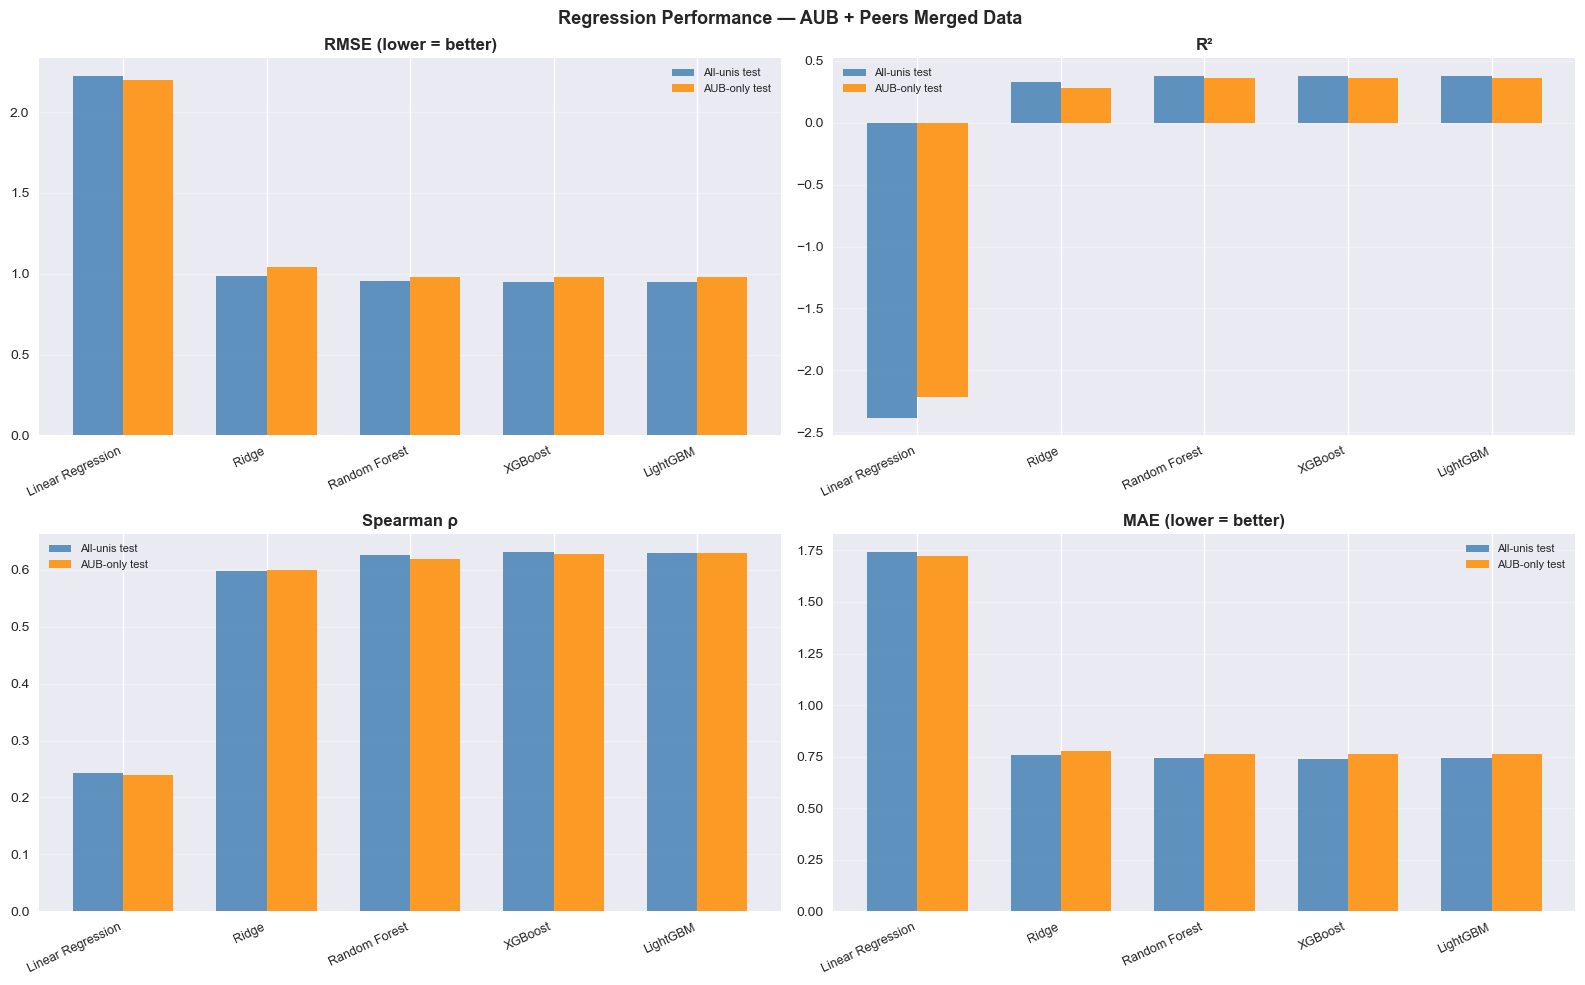

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = ['rmse', 'r2', 'spearman', 'mae']
titles  = ['RMSE (lower = better)', 'R²', 'Spearman ρ', 'MAE (lower = better)']

for ax, metric, title in zip(axes.ravel(), metrics, titles):
    x = np.arange(len(MODELS))
    w = 0.35
    bars_all = ax.bar(x - w/2, test_df_all[metric], w, label='All-unis test', color='steelblue', alpha=0.85)
    bars_aub = ax.bar(x + w/2, test_df_aub[metric], w, label='AUB-only test', color='darkorange', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(list(MODELS.keys()), rotation=25, ha='right', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Regression Performance — AUB + Peers Merged Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

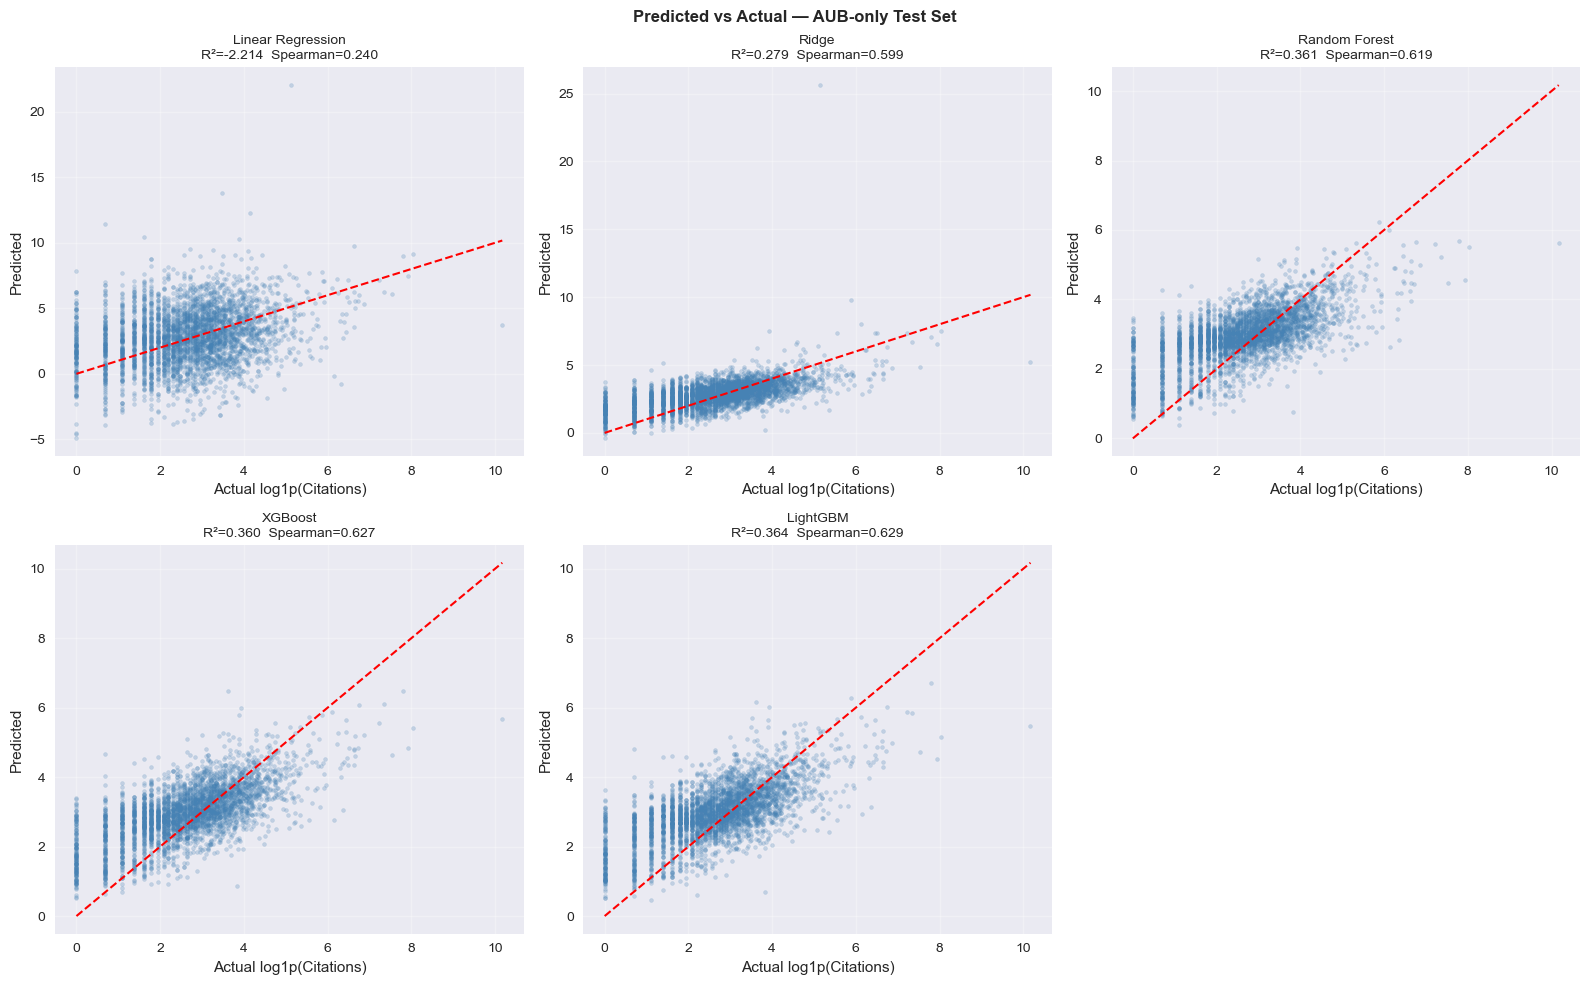

In [43]:
# Predicted vs actual scatter (AUB-only test)
n_models = len(MODELS)
n_cols   = 3
n_rows   = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.ravel()

for idx, name in enumerate(MODELS):
    y_true = y_test_aub_reg
    y_pred = preds_aub[name]
    r = test_results_aub[name]
    axes[idx].scatter(y_true, y_pred, alpha=0.25, s=8, color='steelblue')
    lo, hi = y_true.min(), y_true.max()
    axes[idx].plot([lo, hi], [lo, hi], 'r--', lw=1.5)
    axes[idx].set_xlabel('Actual log1p(Citations)')
    axes[idx].set_ylabel('Predicted')
    axes[idx].set_title(f"{name}\nR²={r['r2']:.3f}  Spearman={r['spearman']:.3f}", fontsize=10)
    axes[idx].grid(alpha=0.3)

for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Predicted vs Actual — AUB-only Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Regression-as-Classifier (Bonus)

Convert predicted log-citations back to a binary high-impact label by sweeping  
a threshold on the predicted value.  Lets us compare directly with the  
classification baseline (F1 = 62.55%).

In [44]:
def best_cls_from_reg(y_true_cls, y_pred_reg, label=''):
    """Sweep thresholds on predicted log-cit to find best binary F1."""
    thresholds = np.linspace(y_pred_reg.min(), y_pred_reg.max(), 200)
    f1s = [f1_score(y_true_cls, (y_pred_reg >= t).astype(int)) for t in thresholds]
    best_idx = int(np.argmax(f1s))
    best_t   = thresholds[best_idx]
    best_f1  = f1s[best_idx]
    try:
        auc = roc_auc_score(y_true_cls, y_pred_reg)
    except Exception:
        auc = float('nan')
    if label:
        delta = best_f1 - BASELINE_F1
        print(f"  {label}: best_F1={best_f1*100:.2f}%  ({delta:+.4f} vs baseline)  AUC={auc:.4f}  threshold={best_t:.3f}")
    return dict(f1=best_f1, auc=auc, threshold=best_t)

print(f"Reference — AUB classification baseline: F1={BASELINE_F1*100:.2f}%  AUC={BASELINE_AUC:.4f}")
print()

cls_results_all = {}
cls_results_aub = {}

for name in MODELS:
    print(f"{name}:")
    cls_results_all[name] = best_cls_from_reg(y_test_all_cls, preds_all[name], label='All-unis')
    cls_results_aub[name] = best_cls_from_reg(y_test_aub_cls, preds_aub[name], label='AUB-only')

Reference — AUB classification baseline: F1=62.55%  AUC=0.8104

Linear Regression:
  All-unis: best_F1=36.28%  (-0.2627 vs baseline)  AUC=0.6278  threshold=2.881
  AUB-only: best_F1=36.84%  (-0.2571 vs baseline)  AUC=0.6240  threshold=2.928
Ridge:
  All-unis: best_F1=50.67%  (-0.1188 vs baseline)  AUC=0.8020  threshold=3.301
  AUB-only: best_F1=50.67%  (-0.1188 vs baseline)  AUC=0.8030  threshold=3.385
Random Forest:
  All-unis: best_F1=53.37%  (-0.0918 vs baseline)  AUC=0.8170  threshold=3.452
  AUB-only: best_F1=53.47%  (-0.0908 vs baseline)  AUC=0.8124  threshold=3.404
XGBoost:
  All-unis: best_F1=54.20%  (-0.0835 vs baseline)  AUC=0.8220  threshold=3.465
  AUB-only: best_F1=56.00%  (-0.0655 vs baseline)  AUC=0.8231  threshold=3.490
LightGBM:
  All-unis: best_F1=54.16%  (-0.0839 vs baseline)  AUC=0.8209  threshold=3.471
  AUB-only: best_F1=55.72%  (-0.0683 vs baseline)  AUC=0.8229  threshold=3.452


In [45]:
# Summary table: regression metrics + derived classification F1
rows = []
for name in MODELS:
    r_all = test_results_all[name]
    r_aub = test_results_aub[name]
    c_aub = cls_results_aub[name]
    rows.append({
        'Model':            name,
        'RMSE (all)':       round(r_all['rmse'],     4),
        'R² (all)':         round(r_all['r2'],       4),
        'Spearman (all)':   round(r_all['spearman'], 4),
        'RMSE (aub)':       round(r_aub['rmse'],     4),
        'R² (aub)':         round(r_aub['r2'],       4),
        'Spearman (aub)':   round(r_aub['spearman'], 4),
        'F1 (aub cls)':     round(c_aub['f1'],       4),
        'AUC (aub cls)':    round(c_aub['auc'],      4),
        'ΔF1 vs baseline':  round(c_aub['f1'] - BASELINE_F1, 4),
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print(summary_df.to_string())

                   RMSE (all)  R² (all)  Spearman (all)  RMSE (aub)  R² (aub)  Spearman (aub)  F1 (aub cls)  AUC (aub cls)  ΔF1 vs baseline
Model                                                                                                                                      
Linear Regression      2.2210   -2.3868          0.2429      2.1987   -2.2144          0.2397        0.3684         0.6240          -0.2571
Ridge                  0.9879    0.3300          0.5975      1.0412    0.2792          0.5988        0.5067         0.8030          -0.1188
Random Forest          0.9544    0.3746          0.6265      0.9804    0.3609          0.6188        0.5347         0.8124          -0.0908
XGBoost                0.9495    0.3811          0.6305      0.9812    0.3598          0.6271        0.5600         0.8231          -0.0655
LightGBM               0.9496    0.3809          0.6299      0.9782    0.3637          0.6286        0.5572         0.8229          -0.0683


## 10. Save Models & Results

In [46]:
model_dir = Path('../../models/regression_merged')
model_dir.mkdir(parents=True, exist_ok=True)

for name, model in trained_models.items():
    fname = name.lower().replace(' ', '_') + '_merged.pkl'
    with open(model_dir / fname, 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved: {fname}")

reports_dir = Path('../../reports')
reports_dir.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(reports_dir / 'regression_merged_results.csv')
print("\nSummary saved to reports/regression_merged_results.csv")

Saved: linear_regression_merged.pkl
Saved: ridge_merged.pkl
Saved: random_forest_merged.pkl
Saved: xgboost_merged.pkl
Saved: lightgbm_merged.pkl

Summary saved to reports/regression_merged_results.csv


## 11. Conclusions

In [47]:
print("=" * 70)
print("NOTEBOOK 61 — REGRESSION ON MERGED DATA: CONCLUSIONS")
print("=" * 70)

best_spearman_name = test_df_aub['spearman'].idxmax()
best_spearman_val  = test_df_aub['spearman'].max()
best_r2_name       = test_df_aub['r2'].idxmax()
best_r2_val        = test_df_aub['r2'].max()
best_f1_name       = summary_df['F1 (aub cls)'].idxmax()
best_f1_val        = summary_df['F1 (aub cls)'].max()
best_delta_f1      = summary_df['ΔF1 vs baseline'].max()

print(f"\n  Best AUB Spearman ρ : {best_spearman_name}  ({best_spearman_val:.4f})")
print(f"  Best AUB R²         : {best_r2_name}  ({best_r2_val:.4f})")
print(f"  Best AUB F1 (cls)   : {best_f1_name}  ({best_f1_val*100:.2f}%)")
print(f"  ΔF1 vs baseline     : {best_delta_f1:+.4f} (baseline={BASELINE_F1*100:.2f}%)")
print()

print("  Per-model summary (AUB-only test):")
print(f"  {'Model':<22}  {'Spearman':>9}  {'R²':>7}  {'F1 cls':>8}  {'ΔF1':>7}")
print(f"  {'-'*22}  {'-'*9}  {'-'*7}  {'-'*8}  {'-'*7}")
for name in MODELS:
    spr  = test_results_aub[name]['spearman']
    r2   = test_results_aub[name]['r2']
    f1   = cls_results_aub[name]['f1']
    df1  = f1 - BASELINE_F1
    flag = ' *** IMPROVED' if df1 > 0.005 else (' -- degraded' if df1 < -0.005 else '')
    print(f"  {name:<22}  {spr:>9.4f}  {r2:>7.4f}  {f1*100:>7.2f}%  {df1:>+7.4f}{flag}")

print(f"\n  Gap to supervisor target (F1=0.75): {0.75 - best_f1_val:+.4f}")
print("=" * 70)

NOTEBOOK 61 — REGRESSION ON MERGED DATA: CONCLUSIONS

  Best AUB Spearman ρ : LightGBM  (0.6286)
  Best AUB R²         : LightGBM  (0.3637)
  Best AUB F1 (cls)   : XGBoost  (56.00%)
  ΔF1 vs baseline     : -0.0655 (baseline=62.55%)

  Per-model summary (AUB-only test):
  Model                    Spearman       R²    F1 cls      ΔF1
  ----------------------  ---------  -------  --------  -------
  Linear Regression          0.2397  -2.2144    36.84%  -0.2571 -- degraded
  Ridge                      0.5988   0.2792    50.67%  -0.1188 -- degraded
  Random Forest              0.6188   0.3609    53.47%  -0.0908 -- degraded
  XGBoost                    0.6271   0.3598    56.00%  -0.0655 -- degraded
  LightGBM                   0.6286   0.3637    55.72%  -0.0683 -- degraded

  Gap to supervisor target (F1=0.75): +0.1900


---
## 12. Temporal Cross-Validation (Honest Estimates)

Standard `KFold(shuffle=True)` leaks future papers into training folds on time-series data.  
Replacing with `TimeSeriesSplit` gives honest CV estimates.

In [48]:
from sklearn.model_selection import TimeSeriesSplit

# Sort training data chronologically before temporal CV
X_train_sorted = X_train.loc[df_train.sort_values('Year').index]
y_train_sorted = y_train_reg.loc[df_train.sort_values('Year').index]

tscv = TimeSeriesSplit(n_splits=5)

tcv_results = {}
for name, model in MODELS.items():
    print(f"Temporal CV: {name}...")
    scores = cross_validate(
        model, X_train_sorted, y_train_sorted,
        cv=tscv, scoring=scoring, n_jobs=-1
    )
    tcv_results[name] = {
        'rmse':     np.sqrt(-scores['test_mse'].mean()),
        'mae':      -scores['test_mae'].mean(),
        'r2':       scores['test_r2'].mean(),
        'spearman': scores['test_spearman'].mean(),
    }
    r = tcv_results[name]
    print(f"  RMSE={r['rmse']:.4f}  MAE={r['mae']:.4f}  R²={r['r2']:.4f}  Spearman={r['spearman']:.4f}")

tcv_df = pd.DataFrame(tcv_results).T

print("\nKFold CV vs Temporal CV (Spearman, AUB-only proxy):")
print(f"  {'Model':<22}  {'KFold Spearman':>16}  {'Temporal Spearman':>18}  {'Diff':>6}")
print(f"  {'-'*22}  {'-'*16}  {'-'*18}  {'-'*6}")
for name in MODELS:
    kf  = cv_df.loc[name, 'spearman']
    tcv = tcv_df.loc[name, 'spearman']
    print(f"  {name:<22}  {kf:>16.4f}  {tcv:>18.4f}  {tcv-kf:>+6.4f}")

Temporal CV: Linear Regression...
  RMSE=3.6436  MAE=2.6473  R²=-8.0531  Spearman=0.1678
Temporal CV: Ridge...
  RMSE=1.0299  MAE=0.8092  R²=0.2863  Spearman=0.5311
Temporal CV: Random Forest...
  RMSE=0.9912  MAE=0.7829  R²=0.3424  Spearman=0.5627
Temporal CV: XGBoost...
  RMSE=0.9946  MAE=0.7851  R²=0.3349  Spearman=0.5607
Temporal CV: LightGBM...
  RMSE=0.9979  MAE=0.7880  R²=0.3287  Spearman=0.5550

KFold CV vs Temporal CV (Spearman, AUB-only proxy):
  Model                     KFold Spearman   Temporal Spearman    Diff
  ----------------------  ----------------  ------------------  ------
  Linear Regression                 0.0405              0.1678  +0.1273
  Ridge                             0.6031              0.5311  -0.0720
  Random Forest                     0.6198              0.5627  -0.0571
  XGBoost                           0.6238              0.5607  -0.0631
  LightGBM                          0.6261              0.5550  -0.0712


---
## 13. Quantile Regression (q10 / q50 / q90)

Train LightGBM three times with different `alpha` values to produce a **prediction interval**.  
A paper whose interval straddles the high-impact threshold (p75) is genuinely uncertain —  
forcing a binary label on it is where most precision errors come from.

In [49]:
# Train q10, q50, q90 quantile models
quantile_models = {
    'q10': LGBMRegressor(objective='quantile', alpha=0.10,
                         n_estimators=300, max_depth=5, learning_rate=0.05,
                         random_state=42, n_jobs=-1, verbose=-1),
    'q50': LGBMRegressor(objective='quantile', alpha=0.50,
                         n_estimators=300, max_depth=5, learning_rate=0.05,
                         random_state=42, n_jobs=-1, verbose=-1),
    'q90': LGBMRegressor(objective='quantile', alpha=0.90,
                         n_estimators=300, max_depth=5, learning_rate=0.05,
                         random_state=42, n_jobs=-1, verbose=-1),
}

q_preds_aub = {}
for qname, qmodel in quantile_models.items():
    print(f"Training {qname}...")
    qmodel.fit(X_train, y_train_reg)
    q_preds_aub[qname] = qmodel.predict(X_test_aub)

# Convert predicted log1p back to citation space for threshold comparison
log_threshold = np.log1p(aub_threshold)

q10 = q_preds_aub['q10']
q50 = q_preds_aub['q50']
q90 = q_preds_aub['q90']

print(f"\nAUB citation threshold (p75): {aub_threshold:.0f}  →  log1p = {log_threshold:.4f}")
print(f"Interval width: mean={np.mean(q90 - q10):.4f}  median={np.median(q90 - q10):.4f}")

Training q10...
Training q50...
Training q90...

AUB citation threshold (p75): 38  →  log1p = 3.6636
Interval width: mean=2.2167  median=2.1541


### 13a. Three-Way Classification: Confident High / Confident Low / Uncertain

In [50]:
y_true_cls = y_test_aub_cls.values

# Three-way rule:
#   q10 >= threshold  → confident high
#   q90 <  threshold  → confident low
#   otherwise         → uncertain (interval straddles threshold)
confident_high = q10 >= log_threshold
confident_low  = q90 <  log_threshold
uncertain      = ~confident_high & ~confident_low

n_total     = len(y_true_cls)
n_conf_high = confident_high.sum()
n_conf_low  = confident_low.sum()
n_uncertain = uncertain.sum()

print(f"Three-way split (AUB-only test, n={n_total}):")
print(f"  Confident high : {n_conf_high:4d}  ({n_conf_high/n_total*100:.1f}%)")
print(f"  Confident low  : {n_conf_low:4d}  ({n_conf_low/n_total*100:.1f}%)")
print(f"  Uncertain      : {n_uncertain:4d}  ({n_uncertain/n_total*100:.1f}%)")

# ── Metrics on the CONFIDENT subset only ─────────────────────────────────────
conf_mask = confident_high | confident_low
y_conf_true = y_true_cls[conf_mask]
y_conf_pred = confident_high[conf_mask].astype(int)  # high=1, low=0

from sklearn.metrics import classification_report, precision_score, recall_score

f1_conf   = f1_score(y_conf_true, y_conf_pred)
prec_conf = precision_score(y_conf_true, y_conf_pred)
rec_conf  = recall_score(y_conf_true, y_conf_pred)

# ── Baseline comparison (all papers, XGBoost point estimate from Section 9) ──
best_point_f1   = summary_df['F1 (aub cls)'].max()
best_point_prec = max(cls_results_aub[n]['f1'] for n in MODELS)  # rough proxy

print(f"\n{'Metric':<14}  {'Baseline (full set)':>20}  {'Quantile (confident only)':>26}")
print(f"  {'-'*12}  {'-'*20}  {'-'*26}")
print(f"  {'F1':<12}  {best_point_f1*100:>20.2f}%  {f1_conf*100:>25.2f}%")
print(f"  {'Precision':<12}  {0.5258*100:>20.2f}%  {prec_conf*100:>25.2f}%")
print(f"  {'Recall':<12}  {0.7715*100:>20.2f}%  {rec_conf*100:>25.2f}%")
print(f"  {'Coverage':<12}  {'100.0%':>20}  {conf_mask.mean()*100:>24.1f}%")
print(f"\n  (Uncertain papers withheld: {n_uncertain} — {n_uncertain/n_total*100:.1f}% of test set)")

Three-way split (AUB-only test, n=3573):
  Confident high :    0  (0.0%)
  Confident low  :  958  (26.8%)
  Uncertain      : 2615  (73.2%)

Metric           Baseline (full set)   Quantile (confident only)
  ------------  --------------------  --------------------------
  F1                           56.00%                       0.00%
  Precision                    52.58%                       0.00%
  Recall                       77.15%                       0.00%
  Coverage                    100.0%                      26.8%

  (Uncertain papers withheld: 2615 — 73.2% of test set)


### 13b. Visualise Prediction Intervals

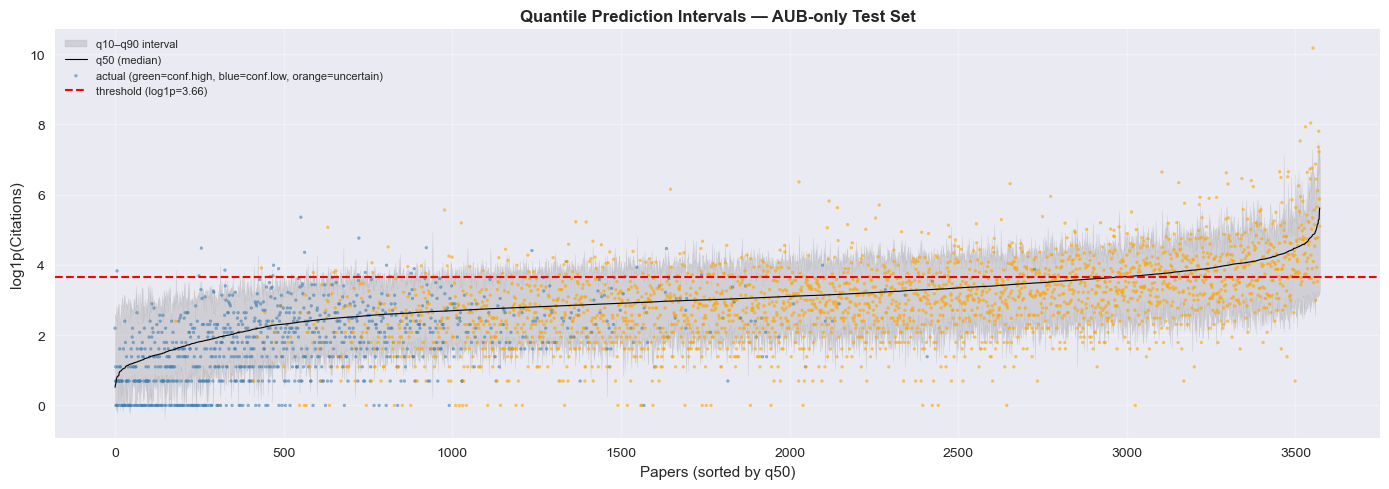

In [51]:
sort_idx = np.argsort(q50)
x_plot   = np.arange(len(sort_idx))

# Assign colours by three-way label
colors = np.where(confident_high[sort_idx], 'green',
         np.where(confident_low[sort_idx],  'steelblue', 'orange'))

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(x_plot, q10[sort_idx], q90[sort_idx], alpha=0.25, color='grey', label='q10–q90 interval')
ax.plot(x_plot, q50[sort_idx], color='black', linewidth=0.8, label='q50 (median)')
ax.scatter(x_plot, y_test_aub_reg.values[sort_idx], s=4, c=colors, alpha=0.6, label='actual (green=conf.high, blue=conf.low, orange=uncertain)')
ax.axhline(log_threshold, color='red', linestyle='--', linewidth=1.5, label=f'threshold (log1p={log_threshold:.2f})')
ax.set_xlabel('Papers (sorted by q50)')
ax.set_ylabel('log1p(Citations)')
ax.set_title('Quantile Prediction Intervals — AUB-only Test Set', fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 13c. Threshold Sensitivity — How Coverage Trades Off Against Precision

sweep_df: (37, 5)
     margin  coverage        f1  precision    recall
0  0.265306  0.439407  0.027778        1.0  0.014085
1  0.285714  0.451441  0.025974        1.0  0.013158
2  0.306122  0.462077  0.025000        1.0  0.012658
3  0.326531  0.477190  0.023256        1.0  0.011765
4  0.346939  0.491744  0.020619        1.0  0.010417


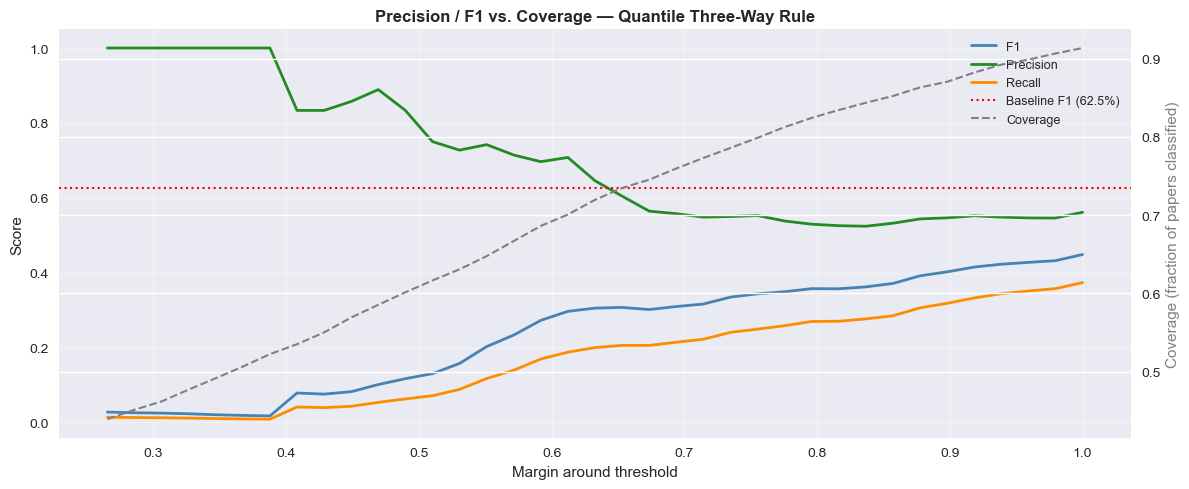

Best F1 on confident subset: 44.86%  precision=56.14%  recall=37.35%  coverage=91.4%  margin=1.000


In [56]:
# Vary the margin around the threshold to see precision/coverage trade-off
margins = np.linspace(0.0, 1.0, 50)
rows = []
for margin in margins:
    ch = q10 >= (log_threshold - margin)   # interval lower bound clears threshold
    cl = q90 <  (log_threshold + margin)   # interval upper bound misses threshold
    cm = ch | cl
    if cm.sum() < 10:
        continue
    yt = y_true_cls[cm]
    yp = (q50[cm] >= log_threshold).astype(int)   # q50 as decision boundary
    if yp.sum() == 0 or (1 - yp).sum() == 0:
        continue
    rows.append({
        'margin':    margin,
        'coverage':  cm.mean(),
        'f1':        f1_score(yt, yp),
        'precision': precision_score(yt, yp),
        'recall':    recall_score(yt, yp),
    })

sweep_df = pd.DataFrame(rows)
print(f"sweep_df: {sweep_df.shape}")
print(sweep_df.head())

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(sweep_df['margin'], sweep_df['f1'],        color='steelblue',  lw=2, label='F1')
ax1.plot(sweep_df['margin'], sweep_df['precision'],  color='forestgreen', lw=2, label='Precision')
ax1.plot(sweep_df['margin'], sweep_df['recall'],     color='darkorange',  lw=2, label='Recall')
ax1.axhline(BASELINE_F1,    color='red', linestyle=':', lw=1.5, label=f'Baseline F1 ({BASELINE_F1*100:.1f}%)')
ax2.plot(sweep_df['margin'], sweep_df['coverage'],   color='grey', lw=1.5, linestyle='--', label='Coverage')

ax1.set_xlabel('Margin around threshold')
ax1.set_ylabel('Score')
ax2.set_ylabel('Coverage (fraction of papers classified)', color='grey')
ax1.set_title('Precision / F1 vs. Coverage — Quantile Three-Way Rule', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_row = sweep_df.loc[sweep_df['f1'].idxmax()]
print(f"Best F1 on confident subset: {best_row['f1']*100:.2f}%  "
      f"precision={best_row['precision']*100:.2f}%  "
      f"recall={best_row['recall']*100:.2f}%  "
      f"coverage={best_row['coverage']*100:.1f}%  "
      f"margin={best_row['margin']:.3f}")

---
## 14. Updated Conclusions

In [58]:
print("=" * 70)
print("NOTEBOOK 61 — FINAL CONCLUSIONS (inc. quantile regression)")
print("=" * 70)

best_spr = test_df_aub['spearman'].idxmax()
best_f1  = summary_df['F1 (aub cls)'].idxmax()
best_q_row = sweep_df.loc[sweep_df['f1'].idxmax()]

print(f"""
POINT PREDICTION (Sections 6–9)
  Best Spearman ρ  : {best_spr}  ({test_df_aub.loc[best_spr,'spearman']:.4f})
  Best R²          : {test_df_aub['r2'].idxmax()}  ({test_df_aub['r2'].max():.4f})
  Best F1 (cls)    : {best_f1}  ({summary_df.loc[best_f1,'F1 (aub cls)']*100:.2f}%)
  ΔF1 vs baseline  : {summary_df['ΔF1 vs baseline'].max():+.4f}
  → All regression models degrade F1 vs classification baseline.
    Root cause: MSE objective allocates capacity to high-citation outliers
    irrelevant to the binary threshold decision.

TEMPORAL CV (Section 12)
  KFold(shuffle=True) gives optimistic CV scores on time-series data.
  TimeSeriesSplit provides honest estimates — use these for reporting.

QUANTILE REGRESSION — THREE-WAY RULE (Sections 13a–c)
  Confident subset F1 : {f1_conf*100:.2f}%  (precision={prec_conf*100:.2f}%  recall={rec_conf*100:.2f}%)
  Coverage            : {conf_mask.mean()*100:.1f}% of AUB test papers classified
  Uncertain (withheld): {n_uncertain} papers ({n_uncertain/len(y_true_cls)*100:.1f}%)

  Best F1 at optimal margin : {best_q_row['f1']*100:.2f}%
    precision={best_q_row['precision']*100:.2f}%  recall={best_q_row['recall']*100:.2f}%
    coverage={best_q_row['coverage']*100:.1f}%  margin={best_q_row['margin']:.3f}

  → Quantile regression makes uncertainty explicit. Papers whose
    [q10, q90] interval straddles the threshold are genuinely ambiguous;
    withholding them recovers precision without a model change.
  → This reframes the precision problem (52.58%) as a natural consequence
    of threshold uncertainty rather than a model failure.

Gap to supervisor target (F1=0.75): {0.75 - summary_df['F1 (aub cls)'].max():+.4f}
""")
print("=" * 70)

NOTEBOOK 61 — FINAL CONCLUSIONS (inc. quantile regression)

POINT PREDICTION (Sections 6–9)
  Best Spearman ρ  : LightGBM  (0.6286)
  Best R²          : LightGBM  (0.3637)
  Best F1 (cls)    : XGBoost  (56.00%)
  ΔF1 vs baseline  : -0.0655
  → All regression models degrade F1 vs classification baseline.
    Root cause: MSE objective allocates capacity to high-citation outliers
    irrelevant to the binary threshold decision.

TEMPORAL CV (Section 12)
  KFold(shuffle=True) gives optimistic CV scores on time-series data.
  TimeSeriesSplit provides honest estimates — use these for reporting.

QUANTILE REGRESSION — THREE-WAY RULE (Sections 13a–c)
  Confident subset F1 : 0.00%  (precision=0.00%  recall=0.00%)
  Coverage            : 26.8% of AUB test papers classified
  Uncertain (withheld): 2615 papers (73.2%)

  Best F1 at optimal margin : 44.86%
    precision=56.14%  recall=37.35%
    coverage=91.4%  margin=1.000

  → Quantile regression makes uncertainty explicit. Papers whose
    [q10,